# Stochastic Approximation

## Root finding algorithm:
- It is a numerical method used to approximate the values of $x$ for which a given continuous function $f(x)$ equals zero, also known as the functions 'root'.

## Stochastic Approximation
- Stochastic Approximation methods are a family of iterative methods typically used for root-finding problems or for optimization problems
- Compared to many other root-finding algorithm such as gradient-based methods, `stochastic approximation` is powerful in the sense that it does not require knowing the expression of the objective function or its derivative.
- `objective function` is a function that is desired to maximize or minimize.

## Robbins-Monro (RM) algorithm
- The RM algorithm is a classical algorithm in stochastic approximation theory to find the root of an equation when only noisy observations are available.

---
- `Problem statement:`
  You want to find the value of $w$ such that the given equation is satisfied 


   $\begin{aligned}
        &&&&&&&g(w) = 0
    \end{aligned}$

but you do not know the expression of $g(.)$ and can only have the noisy observation $\tilde{g}(w_k, \eta_k)$

---
- `RM Algorith:`

  $\begin{align}
  &&&&&&w_{k+1} = w_k - a_k * \tilde{g}(w_k, \eta_k)
  \end{align}$
- where,
  - $w_k$ = kth estimation of the root
  - $\tilde{g}(w_k, \eta_k) = g(w_k) + \eta_k$ ; is the noisy observation
  

  

Let's implement RM algorithm from scratch

In [24]:
import math
import numpy as np
from matplotlib import pyplot as plt

In [37]:
# defining g(wk, nk)
def noisy_tanh(x, sigma=0.1):
    noise = np.random.normal(loc=0.0, scale=sigma)
    return math.tanh(x) + noise

we want to find x such that tanh(x) = 0 and we already know that for x=0, tanh(x) = 0.

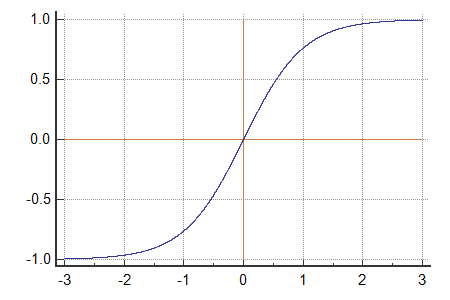

In [86]:
def rm_algorithm(noisy_g_func, n_steps):
    w = 0
    w_history = []
    for k in range(1, n_steps):
        a_k = 1/k
        w = w - a_k * noisy_g_func(w)
        w_history.append(w)
    return w, w_history

In [87]:
x, x_history = rm_algorithm(noisy_tanh, 500)
print("The root x = ", x)

The root x =  -0.0014668252819927655


## Plot X history

In [88]:
def plot_line_graph(y_values, x_start=0, x_step=1, title="Line Plot", xlabel="iteration", ylabel="mean"):
    x_values = np.arange(
        x_start,
        x_start + x_step * len(y_values),
        x_step
    )
    plt.figure(figsize=(16, 4))
    plt.plot(x_values, y_values, marker='o', markersize=1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

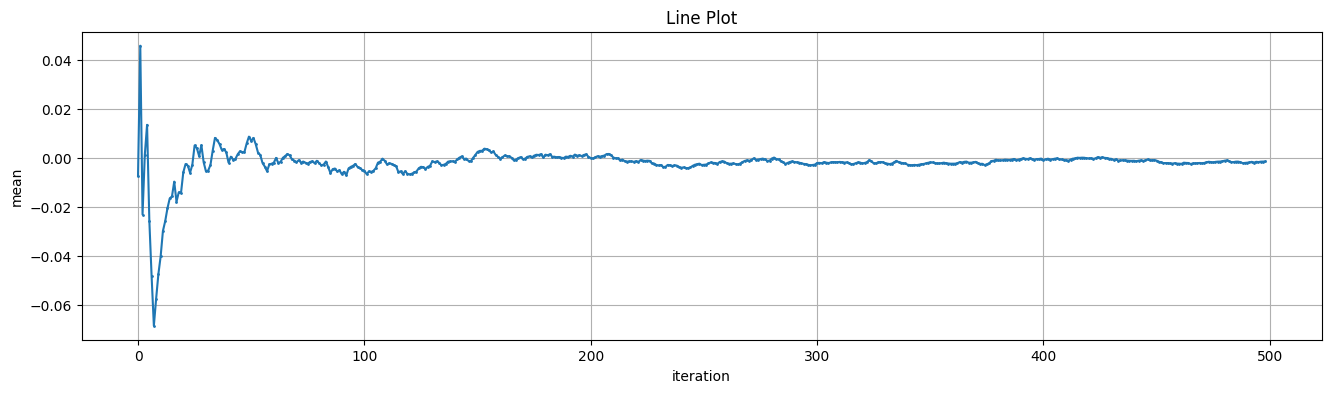

In [89]:
plot_line_graph(x_history)

We can clearly see that over time, the approximation gets better and reaches to the true root value.

# Implement RM algorithm to mean estimation

Consider a function,

$\begin{align}
&&&& g(w) = W - E[X]
\end{align}$

our aim is to solve $g(w) = 0$, so that we can obtain 

$\begin{align}
&& W-E[X] = 0\\
&& or, W = E[X]
\end{align}$

---
The observation we can get is

$\tilde{g}(w, x) = w - x$

because we can only obtain the sample of X.

---

Note that:

$\begin{align}
\tilde{g}(w, \eta) = W - x\\
& = W - x + E[X] - E[X]\\
& = (W - E[X]) + (E[X] - x)\\
& = g(w) + \eta
\end{align}$


In order to apply RM algorithm to estimate mean, we have to set $\tilde{g}$ as

$\begin{align}
&&&&& \tilde{g} = w - x
\end{align}$


In [111]:
def rm_mean_approx(samples):
    w = 0
    w_history = []
    for k, x in enumerate(samples, 1):
        a_k = 1/k
        w = w - a_k * (w - x)
        w_history.append(w)
    return w, w_history

In [112]:
# collect N samples
N = 1000
samples = np.random.randint(0, high=10, size=N, dtype='int')
# direct mean calculation
direct_mean = samples.sum()/N

# rm mean approximation
rm_mean, rm_mean_history = rm_mean_approx(samples)

In [113]:
print("direct mean:", direct_mean)
print("rm mean: ", rm_mean)

direct mean: 4.356
rm mean:  4.355999999999992


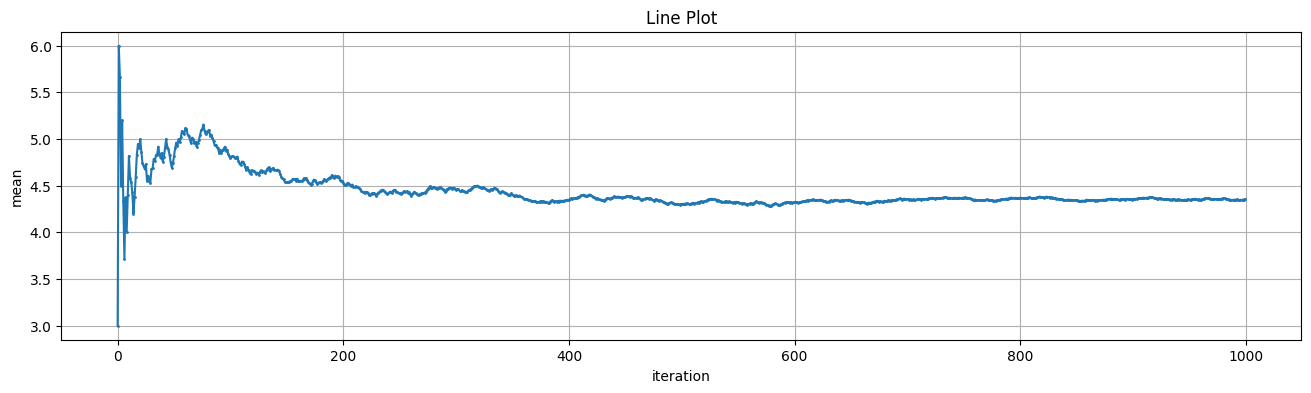

In [114]:
plot_line_graph(rm_mean_history)